## 1. Import Dependencies and Set Random Seed

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, cohen_kappa_score, matthews_corrcoef,
    top_k_accuracy_score, roc_auc_score, log_loss
)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPUs: []


## 2. Load and Inspect the Dataset

In [2]:
train_df = pd.read_csv("/content/mhealth_raw_data.csv")
test_df = pd.read_csv("/content/test.csv")

print("Train:", train_df.shape)
print("Test :", test_df.shape)

display(train_df.head())

Train: (246210, 14)
Test : (64342, 14)


,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,-0.588928,0.752533,0.845374,0.097572,-0.641033,-0.011377,-0.855611,-0.131885,0.143898,-1.332491,0.925267,-0.284586,0,subject1
1,-0.184615,0.262388,-0.947074,-0.767320,0.965526,-1.752951,0.983525,-0.271961,0.396661,-0.018579,-1.211323,-0.123642,0,subject8
2,-0.057113,-0.091772,0.073986,-0.783334,-0.474240,1.372718,0.153841,-0.421663,0.349764,-1.232232,-0.787728,-0.069988,0,subject2
3,0.002504,0.104757,-0.511182,-1.079631,0.004216,-1.186625,0.428112,-0.165552,-0.064694,-0.269180,-0.798973,-1.502009,0,subject4
4,-0.508155,-0.076773,0.343761,-1.668232,-0.518132,-0.216693,0.356659,-0.574753,-0.229835,0.156850,-1.005139,-1.658816,0,subject3


## 3. Define Feature, Target, and Group Columns

In [3]:
features = ['alx','aly','alz','glx','gly','glz','arx','ary','arz','grx','gry','grz']
target = "Activity"
group = "subject"

assert all(c in train_df.columns for c in features + [target, group])
assert all(c in test_df.columns for c in features + [target, group])

print("Feature count:", len(features))

Feature count: 12


## 4. Data Cleaning and Index Preparation

In [4]:
train_df = train_df.copy().reset_index(drop=True)
test_df = test_df.copy().reset_index(drop=True)

train_df["row_id"] = np.arange(len(train_df))
test_df["row_id"] = np.arange(len(test_df))

train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

train_df[target] = train_df[target].astype(int)
test_df[target] = test_df[target].astype(int)

print("After cleaning:")
print("Train:", train_df.shape)
print("Test :", test_df.shape)

print("\nMissing values (train):")
print(train_df.isnull().sum().sort_values(ascending=False).head())

After cleaning:
Train: (246210, 15)
Test : (64342, 15)

Missing values (train):
alx    0
aly    0
alz    0
glx    0
gly    0
dtype: int64


## 5. Exploratory Data Analysis

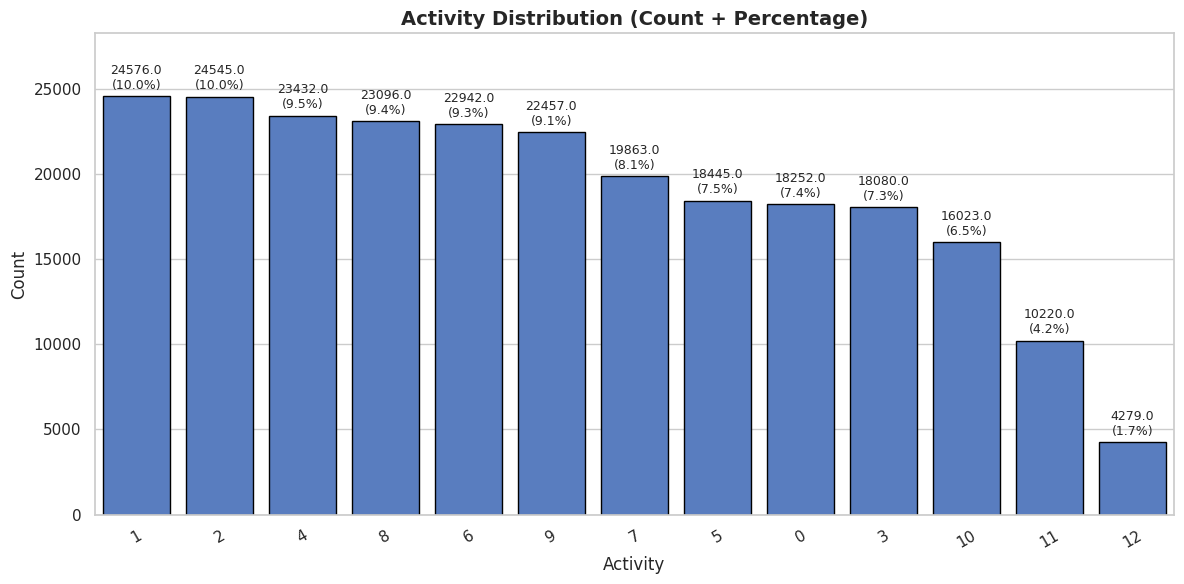

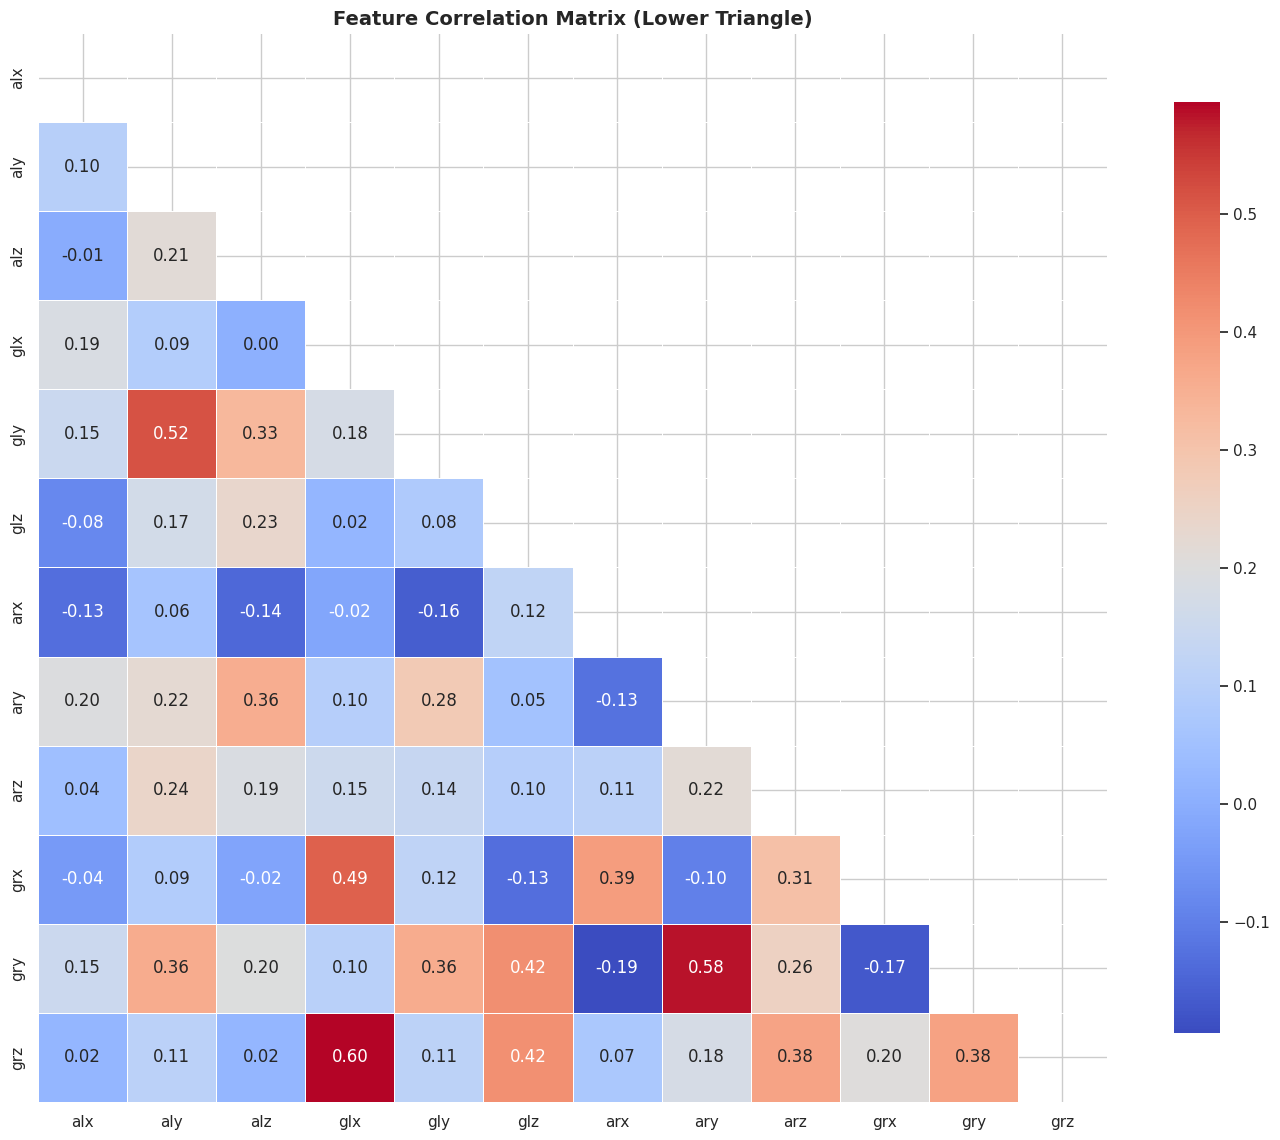

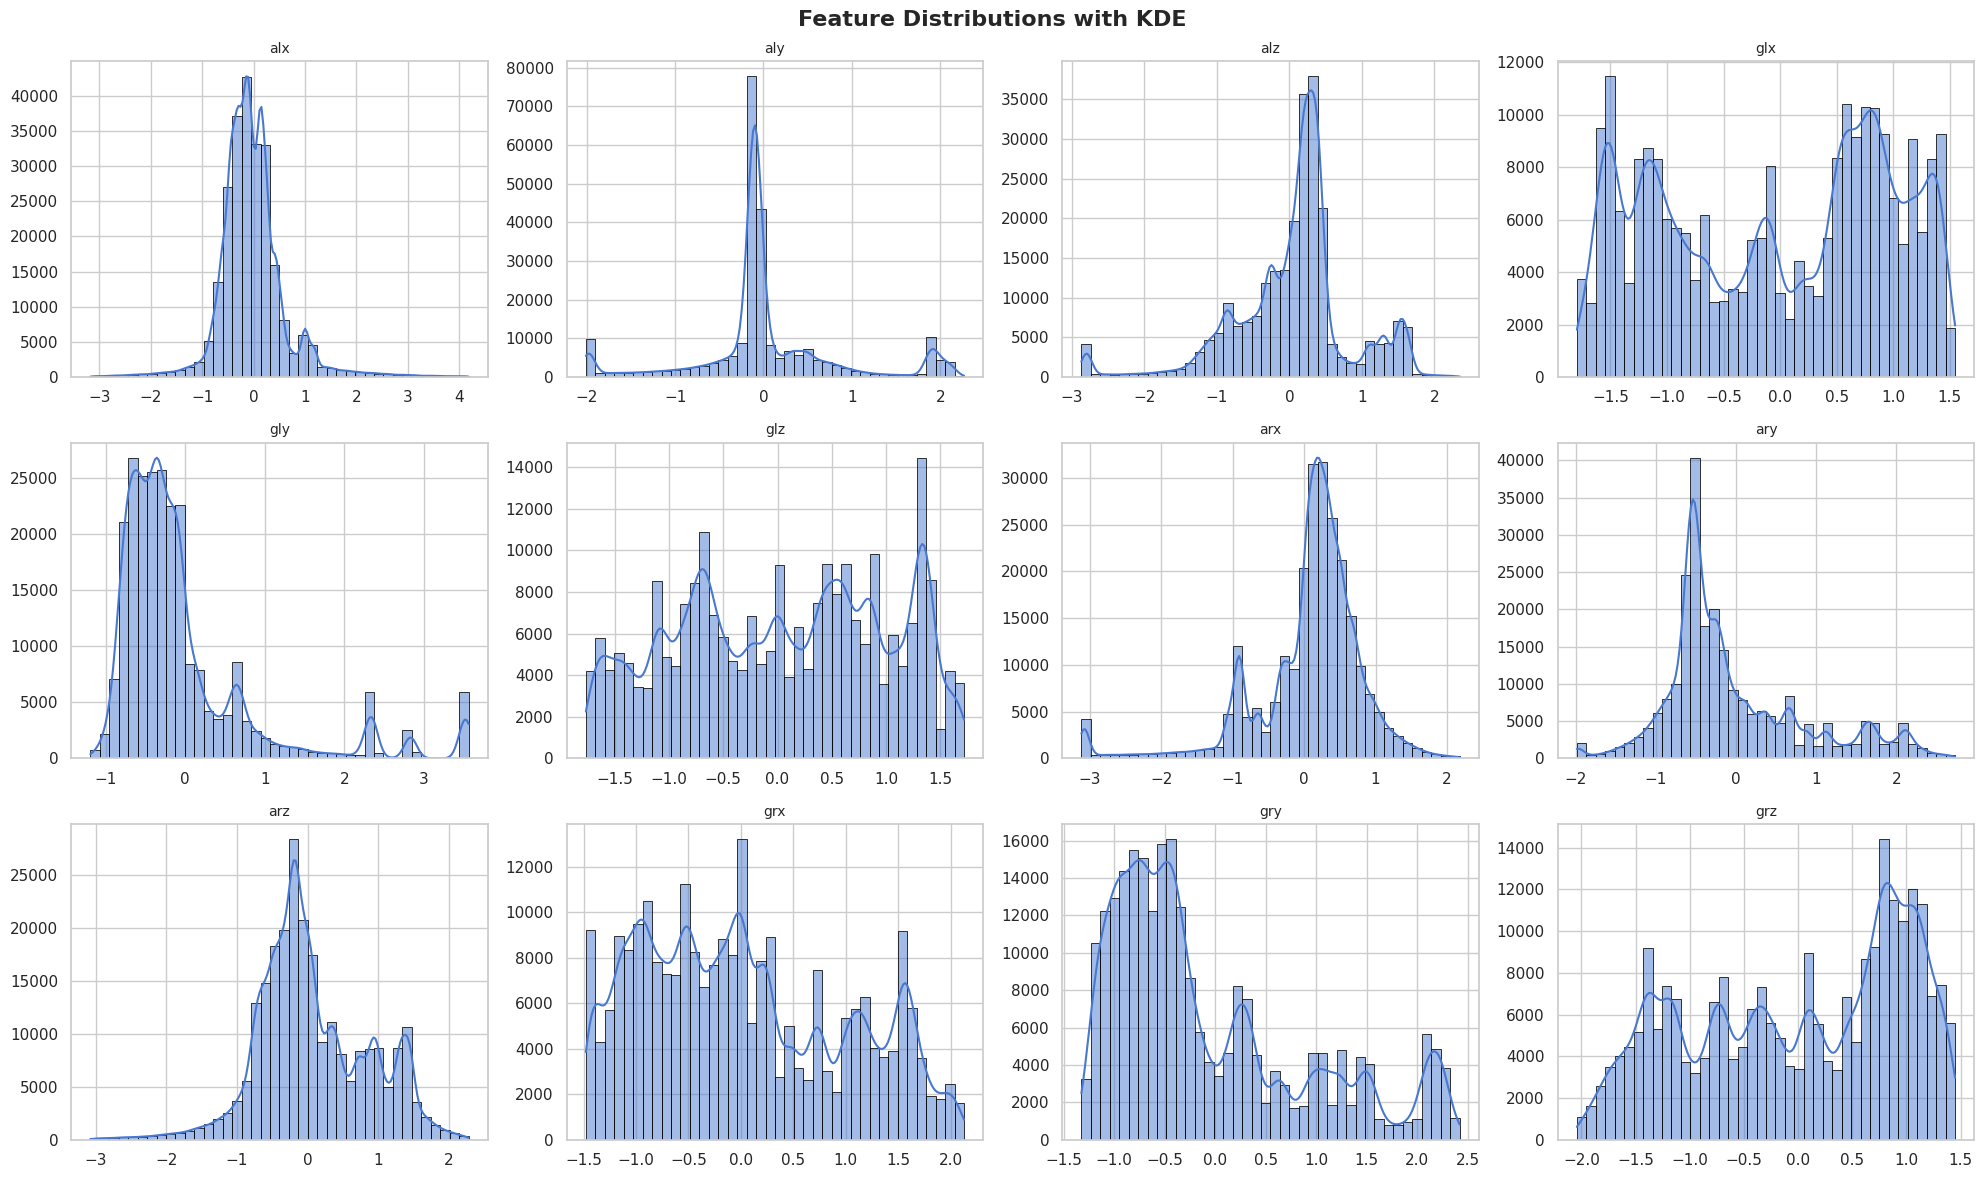

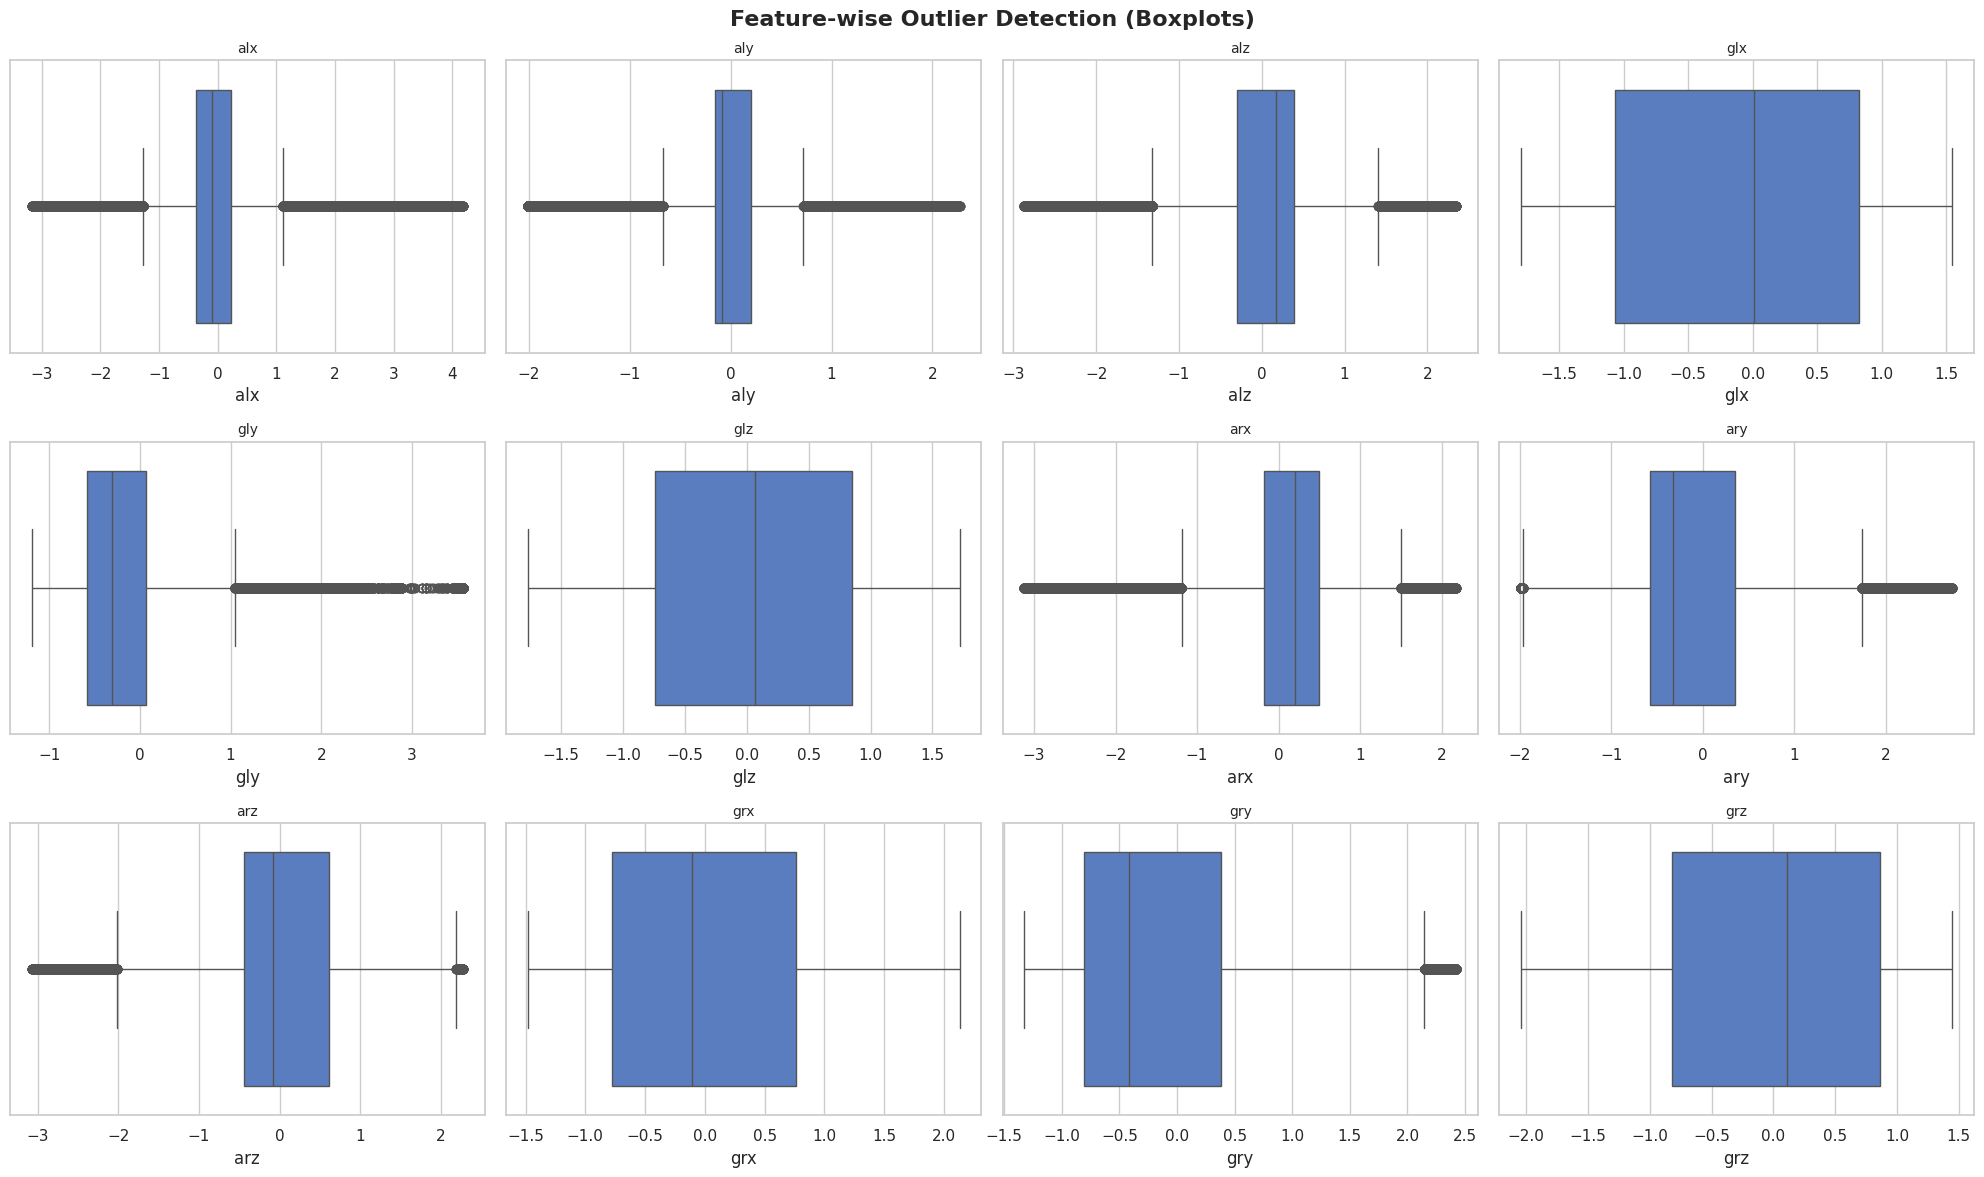

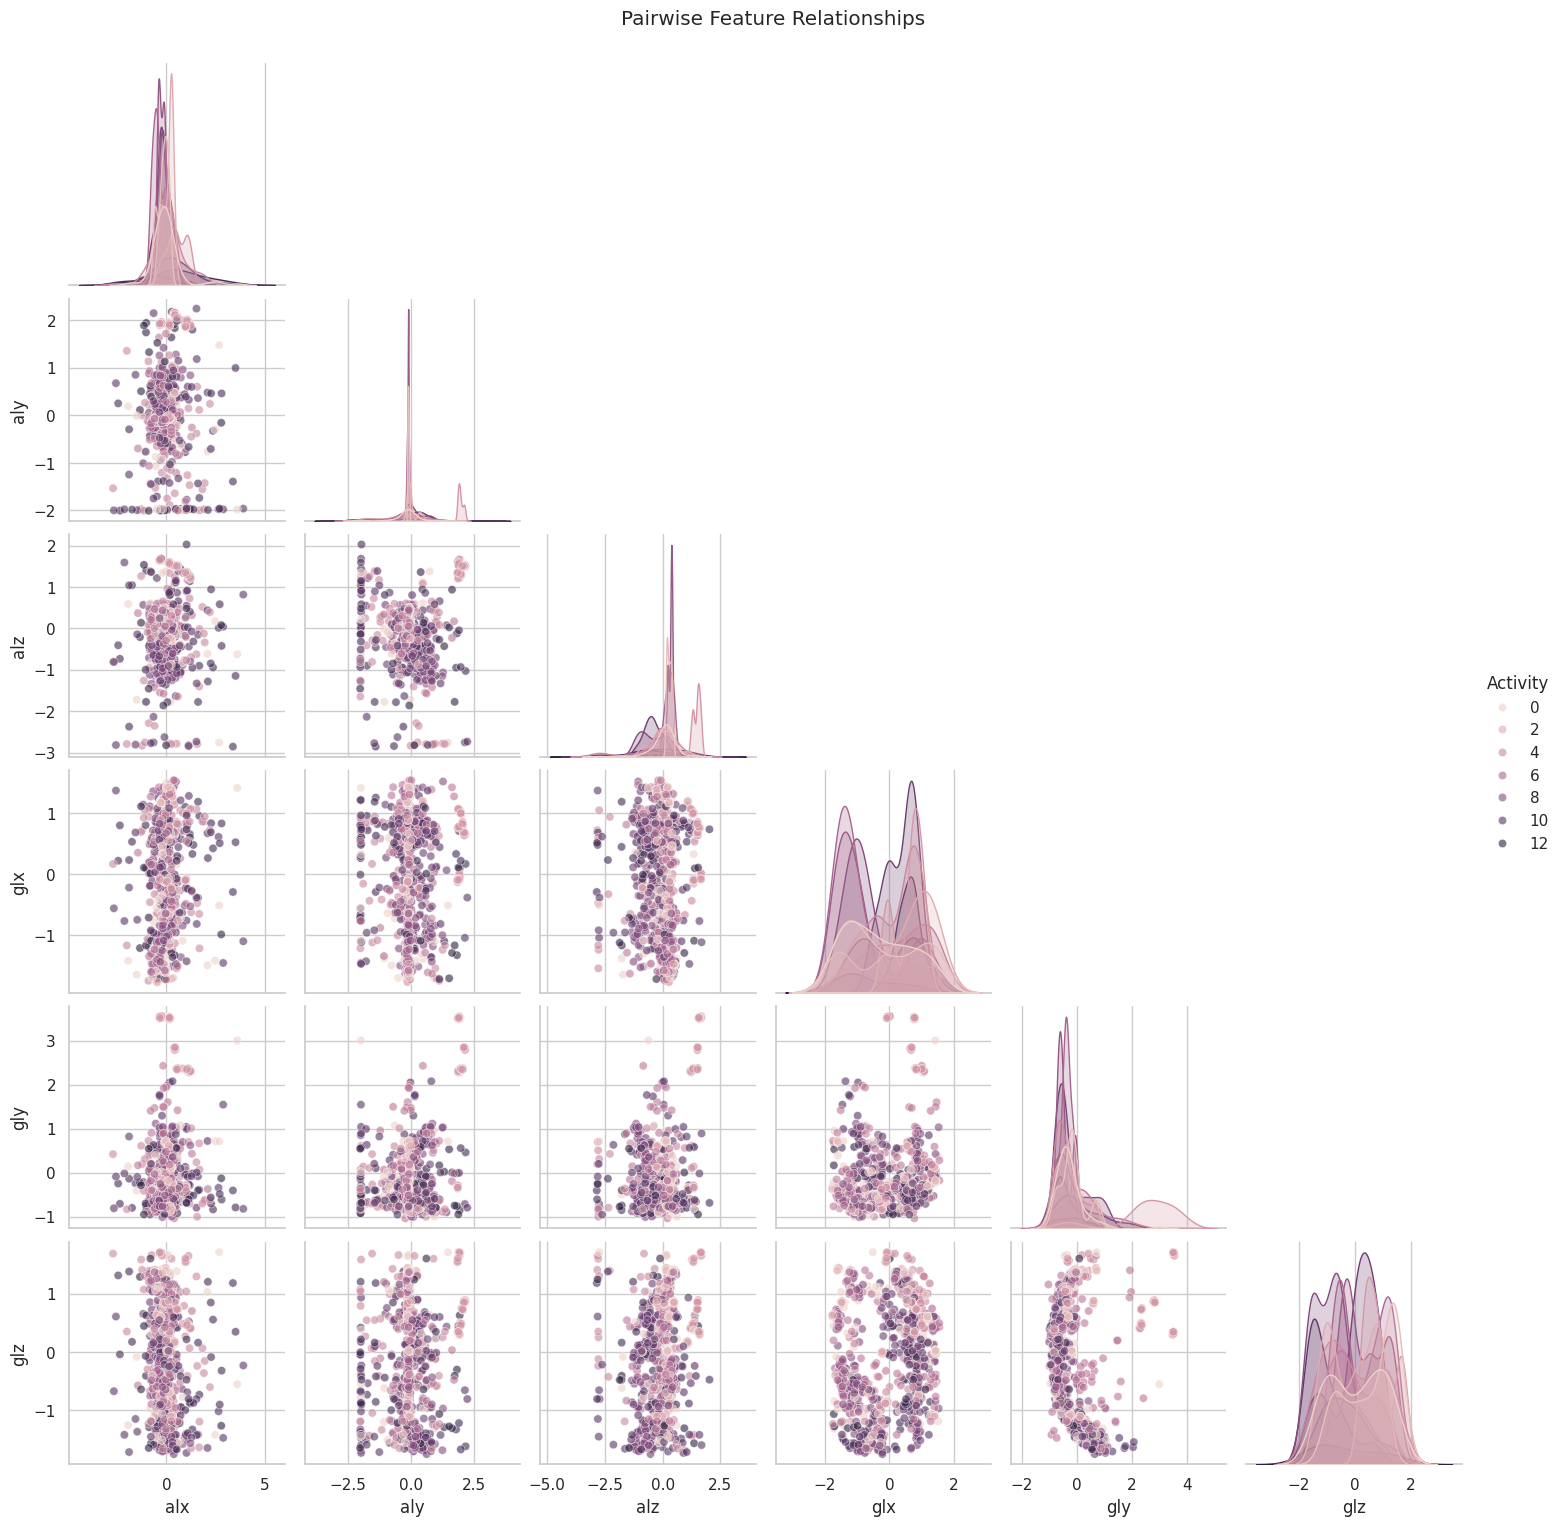

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    x=train_df[target],
    order=train_df[target].value_counts().index,
    edgecolor="black"
)

total = len(train_df)
max_height = max([p.get_height() for p in ax.patches])

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + max_height * 0.01,
        f"{height}\n({height/total:.1%})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, max_height * 1.15)
plt.title("Activity Distribution (Count + Percentage)", fontsize=14, weight='bold')
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

corr = train_df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Matrix (Lower Triangle)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

num_cols = len(features)
cols = 4
rows = int(np.ceil(num_cols / cols))

plt.figure(figsize=(20, rows * 4))

for i, col in enumerate(features):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(
        train_df[col],
        bins=40,
        kde=True,
        edgecolor="black"
    )
    plt.title(col, fontsize=10)
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Feature Distributions with KDE", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, rows * 4))

for i, col in enumerate(features):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=train_df[col])
    plt.title(col, fontsize=10)

plt.suptitle("Feature-wise Outlier Detection (Boxplots)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

sample_df = train_df.sample(min(1000, len(train_df)))

sns.pairplot(
    sample_df,
    vars=features[:6],
    hue=target,
    corner=True,
    plot_kws={"alpha": 0.6}
)

plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

## 6. Label Encoding and Class Mapping

In [ ]:
all_labels = sorted(pd.concat([train_df[target], test_df[target]]).astype(int).unique())
label_to_idx = {lab: i for i, lab in enumerate(all_labels)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}

train_df[target] = train_df[target].map(label_to_idx).astype(int)
test_df[target] = test_df[target].map(label_to_idx).astype(int)

num_classes = len(all_labels)
print("Label mapping:", label_to_idx)
print("Num classes:", num_classes)

Label mapping: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(9): 9, np.int64(10): 10, np.int64(11): 11, np.int64(12): 12}
Num classes: 13


## 7. Subject-Aware Train–Validation Split

In [ ]:
try:
    from sklearn.model_selection import StratifiedGroupKFold
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    train_idx, val_idx = next(splitter.split(train_df, train_df[target], groups=train_df[group]))
    print("Using StratifiedGroupKFold")
except Exception:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    train_idx, val_idx = next(gss.split(train_df, groups=train_df[group]))
    print("Using GroupShuffleSplit")

train_raw = train_df.iloc[train_idx].copy().reset_index(drop=True)
val_raw = train_df.iloc[val_idx].copy().reset_index(drop=True)

print("Train raw:", train_raw.shape)
print("Val raw  :", val_raw.shape)
print("Subject overlap:", len(set(train_raw[group]).intersection(set(val_raw[group]))))

Using StratifiedGroupKFold
Train raw: (183237, 15)
Val raw  : (62973, 15)
Subject overlap: 0


## 8. Feature Standardization

In [ ]:
scaler = StandardScaler()
scaler.fit(train_raw[features])

train_raw.loc[:, features] = scaler.transform(train_raw[features])
val_raw.loc[:, features] = scaler.transform(val_raw[features])
test_df.loc[:, features] = scaler.transform(test_df[features])

print("Scaling done.")

Scaling done.


## 9. Sequence Construction with Purity Filtering

In [ ]:
WINDOW = 96
STRIDE = 24
MIN_PURITY = 0.80

def make_sequences(df, feature_cols, label_col="Activity", subject_col="subject",
                   window=96, stride=24, min_purity=0.80):
    X, y = [], []
    kept, skipped = 0, 0

    df = df.sort_values([subject_col, "row_id"]).reset_index(drop=True)

    for _, g in df.groupby(subject_col, sort=False):
        feats = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g[label_col].to_numpy(dtype=np.int32)
        n = len(g)

        if n < window:
            pad_len = window - n
            feats = np.pad(feats, ((pad_len, 0), (0, 0)), mode="edge")
            labels = np.pad(labels, (pad_len, 0), mode="edge")
            X.append(feats)
            y.append(labels[-1])
            kept += 1
            continue

        for start in range(0, n - window + 1, stride):
            end = start + window
            win_x = feats[start:end]
            win_y = labels[start:end]

            majority = np.bincount(win_y).argmax()
            purity = (win_y == majority).mean()

            if purity < min_purity:
                skipped += 1
                continue

            X.append(win_x)
            y.append(majority)
            kept += 1

    print(f"{subject_col}: kept {kept} windows, skipped {skipped} low-purity windows")
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int32)

X_train, y_train = make_sequences(train_raw, features, target, group, WINDOW, STRIDE, MIN_PURITY)
X_val, y_val = make_sequences(val_raw, features, target, group, WINDOW, STRIDE, MIN_PURITY)
X_test, y_test = make_sequences(test_df, features, target, group, WINDOW, STRIDE, MIN_PURITY)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

subject: kept 7436 windows, skipped 178 low-purity windows
subject: kept 2568 windows, skipped 49 low-purity windows
subject: kept 2618 windows, skipped 56 low-purity windows
X_train: (7436, 96, 12) y_train: (7436,)
X_val  : (2568, 96, 12) y_val  : (2568,)
X_test : (2618, 96, 12) y_test : (2618,)


## 10. Build TensorFlow Data Pipelines

In [ ]:
BATCH_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

## 11. Configuring Computation Strategy

In [ ]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Running on TPU")
except Exception:
    strategy = tf.distribute.get_strategy()
    print("Running on CPU/GPU")

Running on CPU/GPU


## 12. Defining Positional Embedding Layer

In [ ]:
class AddPositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            name="pos_emb",
            shape=(self.sequence_length, self.embed_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, x):
        return x + self.pos_emb

## 13. Defining Residual TCN Block

In [ ]:
def residual_tcn_block(x, filters=64, kernel_size=5, dilation_rate=1, dropout=0.20):
    shortcut = x

    x = layers.Conv1D(
        filters, kernel_size, padding="same",
        dilation_rate=dilation_rate, activation="swish"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.SpatialDropout1D(dropout)(x)

    x = layers.Conv1D(
        filters, kernel_size, padding="same",
        dilation_rate=dilation_rate, activation=None
    )(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.Activation("swish")(x)
    return x

## 14. Defining Transformer Encoder Block

In [ ]:
def transformer_block(x, embed_dim=64, num_heads=4, ff_dim=128, dropout=0.20):
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout
    )(x, x)

    attn = layers.Dropout(0.20)(attn)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ff = layers.Dense(ff_dim, activation="swish")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(embed_dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

## 15. Building the Hybrid Deep Learning Model

In [ ]:
with strategy.scope():
    def build_model(window, n_features, num_classes):
        inputs = keras.Input(shape=(window, n_features))

        x = layers.GaussianNoise(0.01)(inputs)

        x = layers.Conv1D(64, 3, padding="same", activation="swish")(x)
        x = layers.BatchNormalization()(x)
        x = layers.SpatialDropout1D(0.10)(x)

        x = residual_tcn_block(x, filters=64, kernel_size=5, dilation_rate=1, dropout=0.20)
        x = residual_tcn_block(x, filters=64, kernel_size=5, dilation_rate=2, dropout=0.20)

        x = layers.Dense(64)(x)
        x = AddPositionEmbedding(window, 64)(x)

        x = transformer_block(x, embed_dim=64, num_heads=4, ff_dim=128, dropout=0.20)
        x = transformer_block(x, embed_dim=64, num_heads=4, ff_dim=128, dropout=0.20)

        avg_pool = layers.GlobalAveragePooling1D()(x)
        max_pool = layers.GlobalMaxPooling1D()(x)
        x = layers.Concatenate()([avg_pool, max_pool])

        x = layers.Dense(96, activation="swish")(x)
        x = layers.Dropout(0.35)(x)
        x = layers.Dense(64, activation="swish")(x)
        x = layers.Dropout(0.25)(x)

        outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
        return keras.Model(inputs, outputs)

    model = build_model(WINDOW, len(features), num_classes)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_2    │ (None, 96, 12)    │          0 │ input_layer_2[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 96, 64)    │      2,368 │ gaussian_noise_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 64)    │        256 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_6 │ (None, 96, 64)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 96, 64)    │     20,544 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 64)    │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_7 │ (None, 96, 64)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 96, 64)    │     20,544 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 64)    │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 96, 64)    │          0 │ spatial_dropout1… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 96, 64)    │          0 │ add_12[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 96, 64)    │     20,544 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 64)    │        256 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_8 │ (None, 96, 64)    │          0 │ batch_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 96, 64)    │     20,544 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 64)    │        256 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 96, 64)    │          0 │ activation_4[0][… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 182,509 (712.93 KB)

 Trainable params: 181,869 (710.43 KB)

 Non-trainable params: 640 (2.50 KB)

## 16. Model Compilation

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_accuracy"),
    ]
)

## 17. Defining Validation Metrics Callback

In [ ]:
class ValMetricsCallback(keras.callbacks.Callback):
    def __init__(self, X_val, y_val, batch_size=256):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.batch_size = batch_size
        self.history = {
            "val_f1_macro": [],
            "val_bal_acc": [],
            "val_precision_macro": [],
            "val_recall_macro": [],
            "val_mcc": [],
            "val_kappa": [],
        }

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.X_val, batch_size=self.batch_size, verbose=0)
        pred = np.argmax(probs, axis=1)

        val_f1 = f1_score(self.y_val, pred, average="macro", zero_division=0)
        val_bal = balanced_accuracy_score(self.y_val, pred)
        val_prec = precision_score(self.y_val, pred, average="macro", zero_division=0)
        val_rec = recall_score(self.y_val, pred, average="macro", zero_division=0)
        val_mcc = matthews_corrcoef(self.y_val, pred)
        val_kappa = cohen_kappa_score(self.y_val, pred)

        self.history["val_f1_macro"].append(val_f1)
        self.history["val_bal_acc"].append(val_bal)
        self.history["val_precision_macro"].append(val_prec)
        self.history["val_recall_macro"].append(val_rec)
        self.history["val_mcc"].append(val_mcc)
        self.history["val_kappa"].append(val_kappa)

        if logs is not None:
            logs["val_f1_macro"] = val_f1
            logs["val_bal_acc"] = val_bal
            logs["val_precision_macro"] = val_prec
            logs["val_recall_macro"] = val_rec
            logs["val_mcc"] = val_mcc
            logs["val_kappa"] = val_kappa

        print(
            f" — val_f1_macro: {val_f1:.4f}"
            f" — val_bal_acc: {val_bal:.4f}"
            f" — val_mcc: {val_mcc:.4f}"
            f" — val_kappa: {val_kappa:.4f}"
        )

## 18. Model Training

In [ ]:
val_metrics_cb = ValMetricsCallback(X_val, y_val, batch_size=BATCH_SIZE)

callbacks = [
    val_metrics_cb,
    keras.callbacks.ModelCheckpoint(
        "/content/best_model.keras",
        monitor="val_f1_macro",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        patience=10,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.1943 - loss: 2.5291 - top2_accuracy: 0.3264 - top3_accuracy: 0.4182 — val_f1_macro: 0.3686 — val_bal_acc: 0.4186 — val_mcc: 0.4230 — val_kappa: 0.4087

Epoch 1: val_f1_macro improved from None to 0.36859, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 967ms/step - accuracy: 0.3214 - loss: 2.1084 - top2_accuracy: 0.5004 - top3_accuracy: 0.5984 - val_accuracy: 0.4603 - val_loss: 1.6513 - val_top2_accuracy: 0.6417 - val_top3_accuracy: 0.7064 - val_f1_macro: 0.3686 - val_bal_acc: 0.4186 - val_precision_macro: 0.4341 - val_recall_macro: 0.4186 - val_mcc: 0.4230 - val_kappa: 0.4087 - learning_rate: 3.0000e-04
Epoch 2/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.6187 - loss: 1.2600 - top2_accuracy: 0.8105 - top3_accuracy: 0.8920 — val_f1_macro: 0.4140 — val_bal_acc: 0.4516 — val_mcc: 0.4634 — val_kappa: 0.4571

Epoch 2: val_f1_ma

## 19. Plotting Training Curves

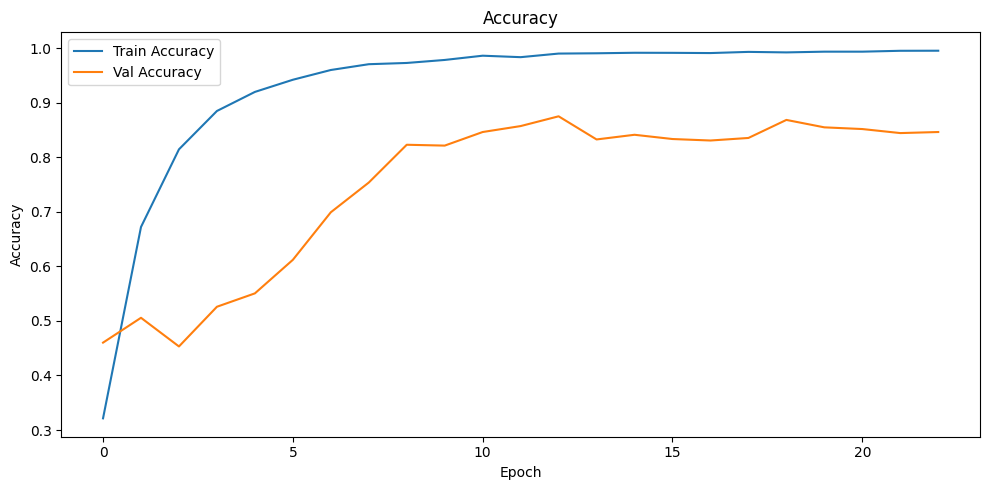

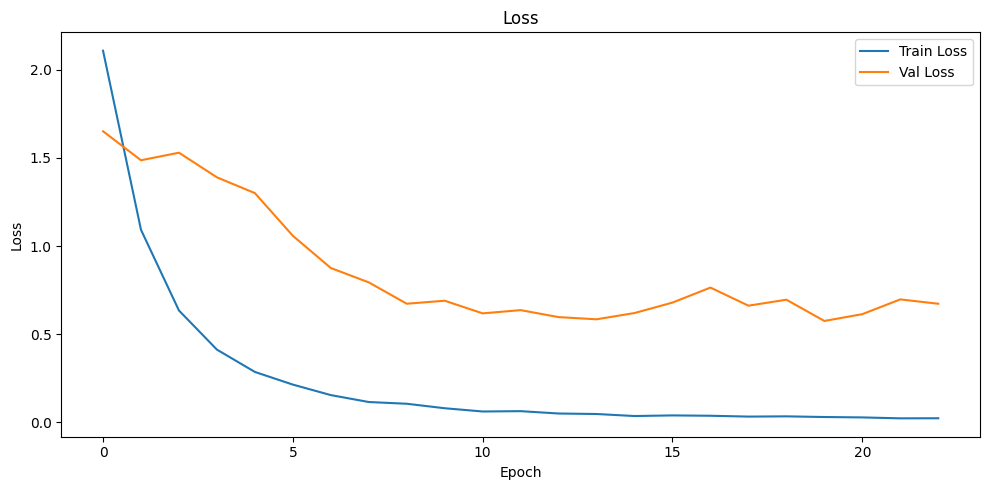

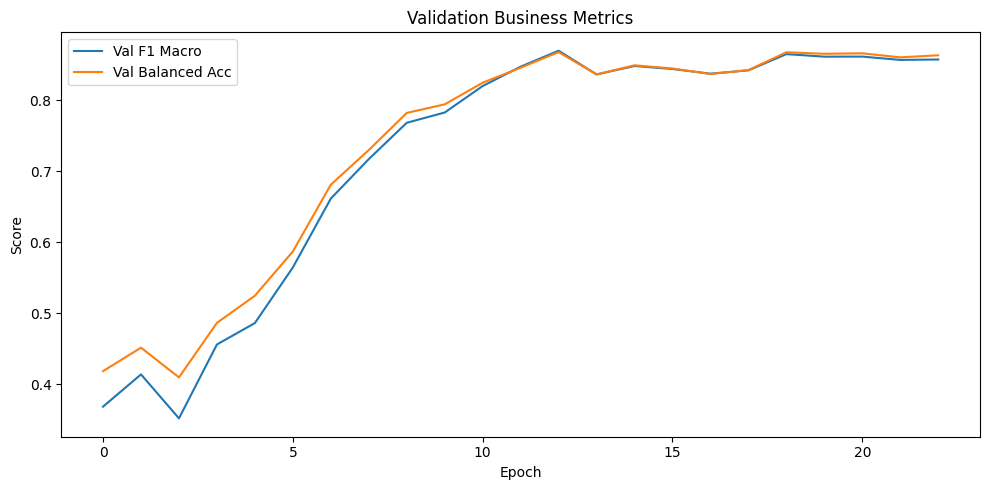

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(val_metrics_cb.history["val_f1_macro"], label="Val F1 Macro")
plt.plot(val_metrics_cb.history["val_bal_acc"], label="Val Balanced Acc")
plt.title("Validation Business Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

## 20. Defining the Evaluation Function

In [ ]:
def evaluate_model(X, y, split_name="SPLIT"):
    probs = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y, pred)
    bal_acc = balanced_accuracy_score(y, pred)
    f1_macro = f1_score(y, pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y, pred, average="weighted", zero_division=0)
    prec_macro = precision_score(y, pred, average="macro", zero_division=0)
    rec_macro = recall_score(y, pred, average="macro", zero_division=0)
    kappa = cohen_kappa_score(y, pred)
    mcc = matthews_corrcoef(y, pred)
    top2 = top_k_accuracy_score(y, probs, k=2, labels=np.arange(num_classes))
    top3 = top_k_accuracy_score(y, probs, k=3, labels=np.arange(num_classes))
    ll = log_loss(y, probs, labels=np.arange(num_classes))

    try:
        y_bin = label_binarize(y, classes=np.arange(num_classes))
        auc_macro = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = np.nan

    print(f"\n{split_name}")
    print("Accuracy           :", round(acc, 4))
    print("Balanced Accuracy   :", round(bal_acc, 4))
    print("F1 Macro            :", round(f1_macro, 4))
    print("F1 Weighted         :", round(f1_weighted, 4))
    print("Precision Macro     :", round(prec_macro, 4))
    print("Recall Macro        :", round(rec_macro, 4))
    print("Cohen Kappa         :", round(kappa, 4))
    print("MCC                 :", round(mcc, 4))
    print("Top-2 Accuracy      :", round(top2, 4))
    print("Top-3 Accuracy      :", round(top3, 4))
    print("Log Loss            :", round(ll, 4))
    print("ROC AUC Macro OVR   :", round(auc_macro, 4) if not np.isnan(auc_macro) else "N/A")
    print()
    print(classification_report(
        y, pred,
        target_names=[str(idx_to_label[i]) for i in range(num_classes)],
        zero_division=0,
        digits=4
    ))

    return probs, pred

## 21. Evaluation on Validation Set


VALIDATION
Accuracy           : 0.8754
Balanced Accuracy   : 0.8675
F1 Macro            : 0.8695
F1 Weighted         : 0.8712
Precision Macro     : 0.9051
Recall Macro        : 0.8675
Cohen Kappa         : 0.864
MCC                 : 0.867
Top-2 Accuracy      : 0.926
Top-3 Accuracy      : 0.9373
Log Loss            : 0.5968
ROC AUC Macro OVR   : 0.9914

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       181
           1     0.9689    0.9881    0.9784       252
           2     0.8811    0.5000    0.6380       252
           3     1.0000    1.0000    1.0000       126
           4     0.9907    0.8954    0.9407       239
           5     0.8289    0.9087    0.8670       208
           6     0.9663    0.6719    0.7926       256
           7     0.6319    1.0000    0.7744       218
           8     0.7462    0.9763    0.8459       253
           9     1.0000    1.0000    1.0000       233
          10     0.9128    0.8500    0.8803     

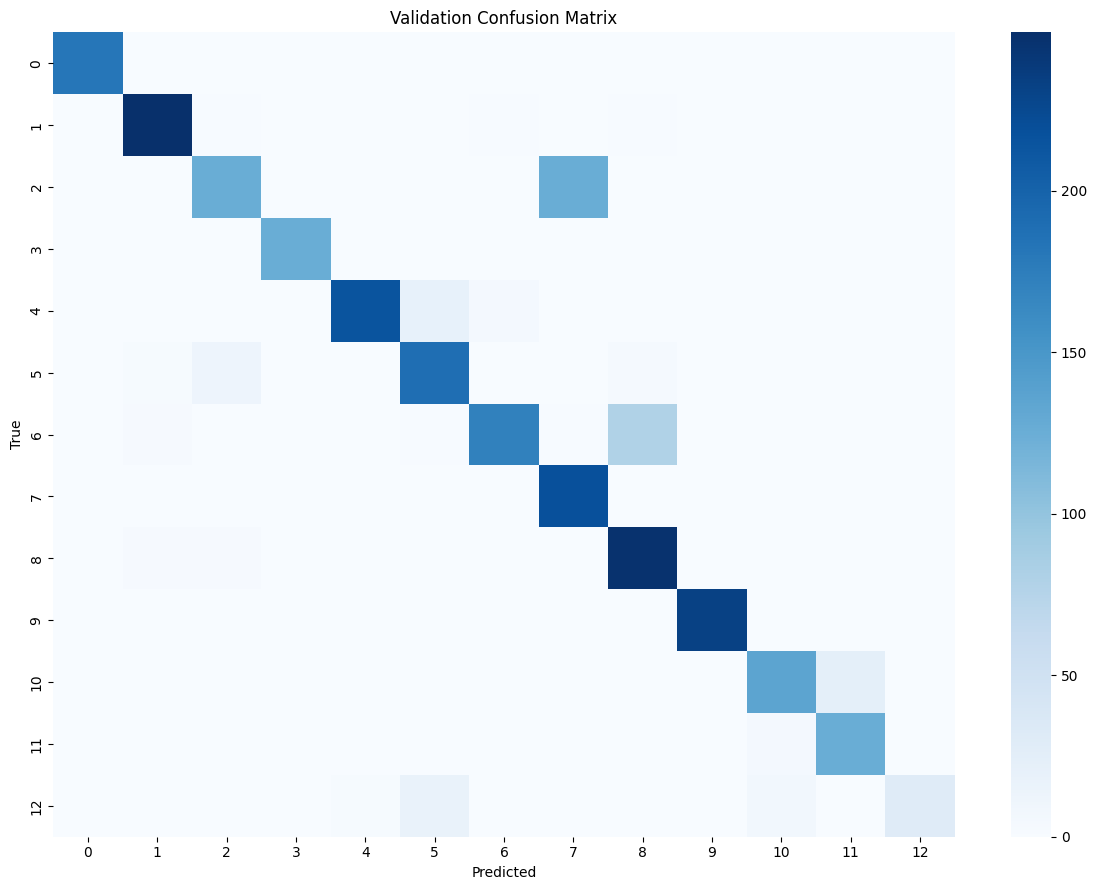

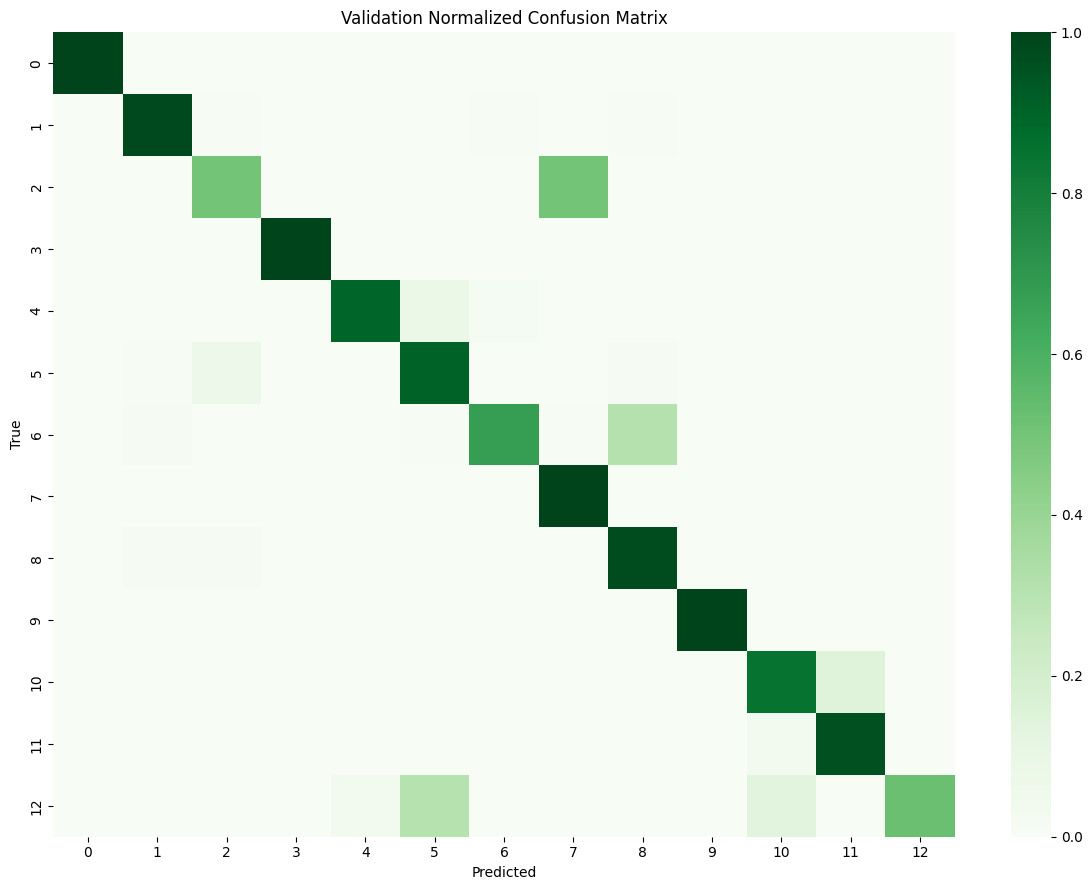

In [ ]:
val_probs, val_pred = evaluate_model(X_val, y_val, split_name="VALIDATION")

cm_val = confusion_matrix(y_val, val_pred)
cm_val_norm = cm_val / np.maximum(cm_val.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(12, 9))
sns.heatmap(cm_val, cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(cm_val_norm, cmap="Greens", vmin=0, vmax=1)
plt.title("Validation Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 22. Evaluation on Test Set


TEST
Accuracy           : 0.9076
Balanced Accuracy   : 0.9182
F1 Macro            : 0.9146
F1 Weighted         : 0.9058
Precision Macro     : 0.9273
Recall Macro        : 0.9182
Cohen Kappa         : 0.8992
MCC                 : 0.9012
Top-2 Accuracy      : 0.9954
Top-3 Accuracy      : 0.9992
Log Loss            : 0.2869
ROC AUC Macro OVR   : 0.9973

              precision    recall  f1-score   support

           0     1.0000    0.9891    0.9945       183
           1     0.9691    1.0000    0.9843       251
           2     0.8344    0.5020    0.6269       251
           3     1.0000    1.0000    1.0000       251
           4     0.9944    0.7306    0.8424       245
           5     0.7026    0.9588    0.8109       170
           6     1.0000    0.9626    0.9810       214
           7     0.6154    0.8734    0.7220       229
           8     0.9713    0.9958    0.9834       238
           9     0.9841    1.0000    0.9920       248
          10     0.9838    1.0000    0.9918       1

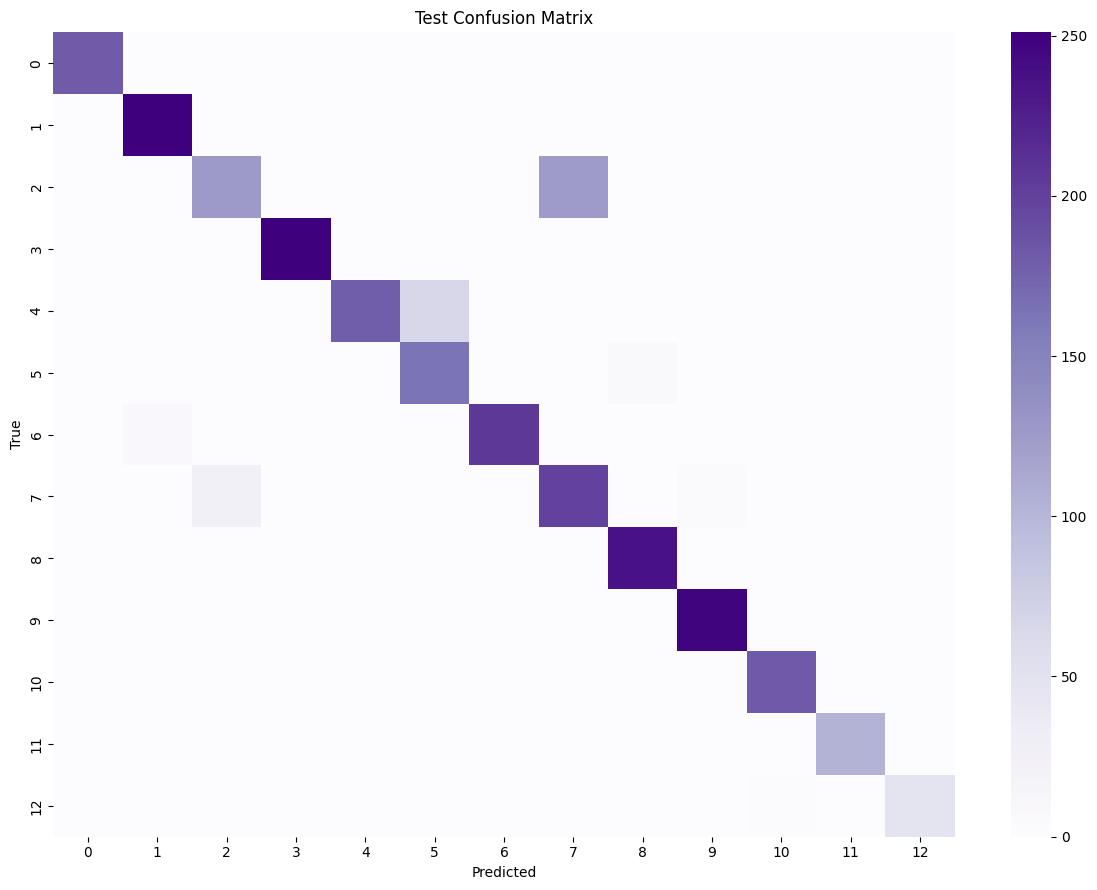

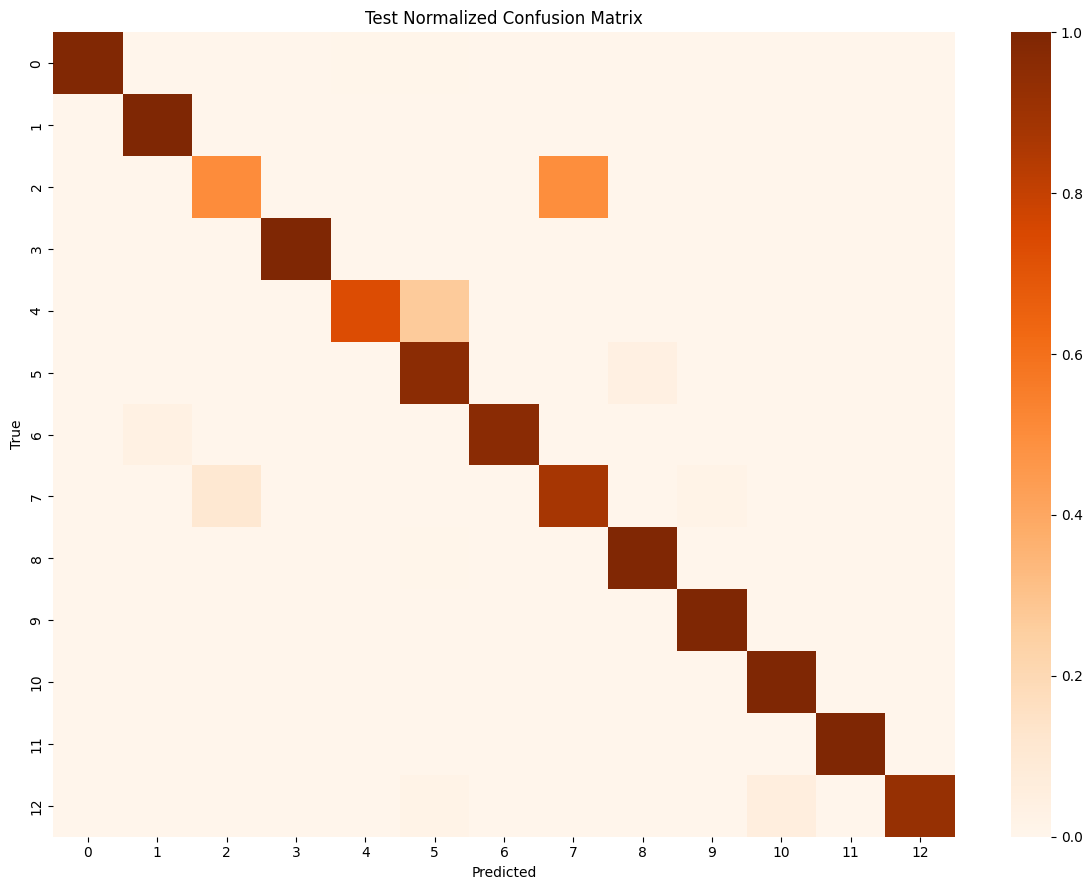

In [ ]:
test_probs, test_pred = evaluate_model(X_test, y_test, split_name="TEST")

cm_test = confusion_matrix(y_test, test_pred)
cm_test_norm = cm_test / np.maximum(cm_test.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(12, 9))
sns.heatmap(cm_test, cmap="Purples")
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(cm_test_norm, cmap="Oranges", vmin=0, vmax=1)
plt.title("Test Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 23. Saving Predictions and Model Artifacts

In [ ]:
pred_df = pd.DataFrame({
    "true_activity_idx": y_test,
    "pred_activity_idx": test_pred,
    "true_activity_raw": [idx_to_label[i] for i in y_test],
    "pred_activity_raw": [idx_to_label[i] for i in test_pred],
})

pred_df.to_csv("/content/test_predictions.csv", index=False)
model.save("/content/final_transformer_model.keras")

import joblib
joblib.dump(scaler, "/content/feature_scaler.pkl")
joblib.dump(label_to_idx, "/content/label_to_idx.pkl")
joblib.dump(idx_to_label, "/content/idx_to_label.pkl")

print("Saved model, predictions, scaler, and label maps.")

Saved model, predictions, scaler, and label maps.
